----------------------------------------------
Import dataset and necessary libraries
----------------------------------------------
----------------------------------------------

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler, LabelEncoder
from numpy import unique, argmax
from scipy.stats.mstats import winsorize
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Input, Dense, Dropout # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from tensorflow.keras.utils import plot_model # type: ignore

df_beam = pd.read_csv("dataset_beam.csv")

print(f"Number of columns: {df_beam.shape[1]}")
print(f"Number of rows: {df_beam.shape[0]}")

pd.set_option('display.width', 1000)
print(df_beam.head())

Number of columns: 30
Number of rows: 3600
  mechanism severity  beam_cm  target_class  distance_crack_cm  distance_wear_cm  crack_mask  wear_mask      FC_Hz    FRMS_Hz  ...  f2_Hz  f3_Hz  f4_Hz  f5_Hz                                          file_path           folder_all  all_index  segment_id   t0     t1
0   healthy     none     10.0             0                0.0               0.0           0          0  21.162511  38.493772  ...   58.0   58.4   57.8   57.6  C:\Users\axelr\OneDrive\Escritorio\Proyecto3\b...              ALL0000          0           1  0.0  4.998
1   healthy     none     10.0             0                0.0               0.0           0          0  18.000610  36.218075  ...   57.6   57.4   57.2   57.0  C:\Users\axelr\OneDrive\Escritorio\Proyecto3\b...      ALL0000 - copia          0           1  0.0  4.998
2   healthy     none     10.0             0                0.0               0.0           0          0  12.107835  31.007700  ...   58.0   57.6   57.4   57.2 

----------------------------------------------
Verifying data types
----------------------------------------------
----------------------------------------------

In [19]:
print("Data Types:")
print(df_beam.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mechanism          3600 non-null   object 
 1   severity           3600 non-null   object 
 2   beam_cm            3600 non-null   float64
 3   target_class       3600 non-null   int64  
 4   distance_crack_cm  3600 non-null   float64
 5   distance_wear_cm   3600 non-null   float64
 6   crack_mask         3600 non-null   int64  
 7   wear_mask          3600 non-null   int64  
 8   FC_Hz              3600 non-null   float64
 9   FRMS_Hz            3600 non-null   float64
 10  FRVF_Hz            3600 non-null   float64
 11  m0                 3600 non-null   float64
 12  m1                 3600 non-null   float64
 13  m2                 3600 non-null   float64
 14  a1                 3600 non-null   float64
 15  a2                 3600 non-null   float64
 16  a3          

----------------------------------------------
Checking for duplicate rows
----------------------------------------------
----------------------------------------------

In [20]:
duplicated = df_beam.duplicated().sum()

if duplicated > 0:
    print(f"{duplicated} duplicated rows in the train set.")
    print("Display of duplicate rows:")
    print(df_beam[df_beam.duplicated()].head())
else:
    print("No duplicate rows were found in the dataset.")

No duplicate rows were found in the dataset.


----------------------------------------------
Obtaining only columns with characteristics
----------------------------------------------
----------------------------------------------

In [21]:
base_cols = [
        "target_class","distance_crack_cm","distance_wear_cm",
        "FC_Hz","FRMS_Hz","FRVF_Hz","m0","m1","m2","a1",
        "a2","a3","a4","a5","f1_Hz","f2_Hz","f3_Hz","f4_Hz","f5_Hz"
    ]

label_cols = ["target_class","distance_crack_cm","distance_wear_cm","crack_mask","wear_mask"]
feature_cols = [c for c in base_cols if c not in label_cols]

labels = df_beam[label_cols].copy()
df_beam_cols = df_beam[feature_cols].copy()


----------------------------------------------
Correlation Map
----------------------------------------------
----------------------------------------------

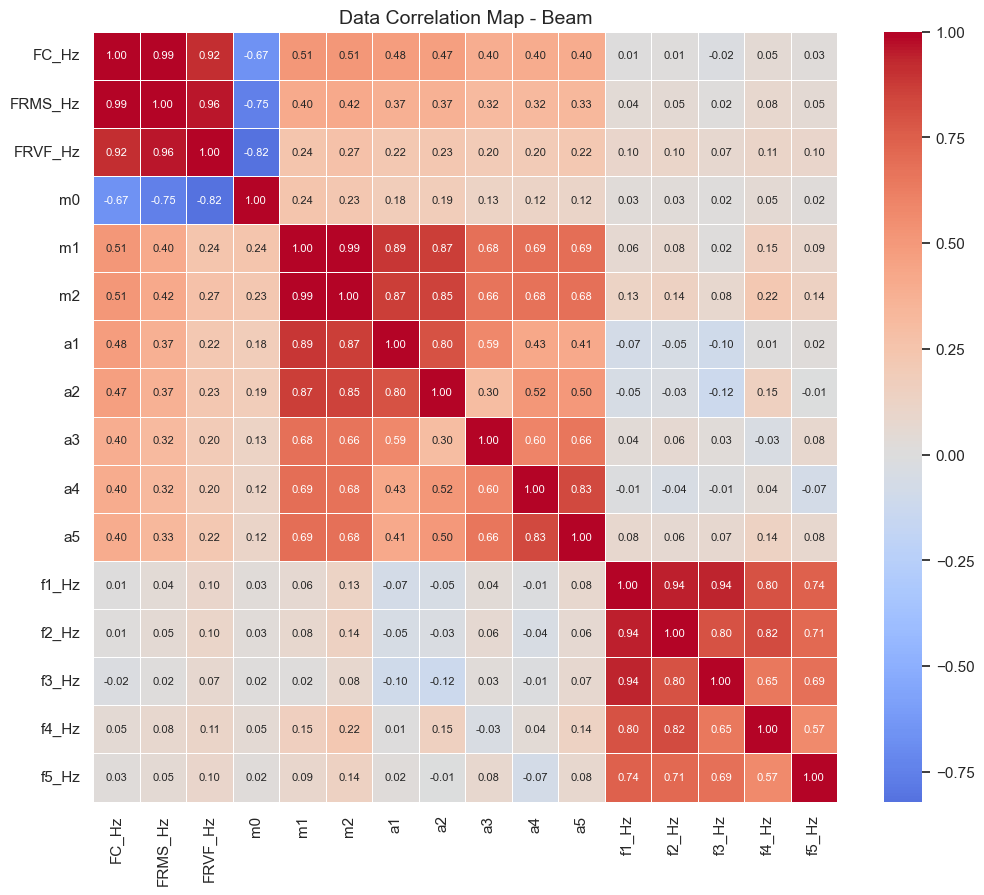

In [22]:
plt.figure(figsize=(12,10)) 
sns.heatmap(df_beam_cols.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            linewidths=0.5, annot_kws={"size": 8}) 
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Data Correlation Map - Beam", fontsize=14)
plt.show()

----------------------------------------------
Distribution of attributes
----------------------------------------------
----------------------------------------------

Original distributions:


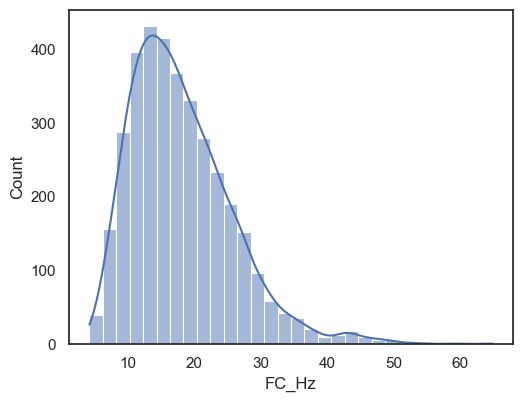

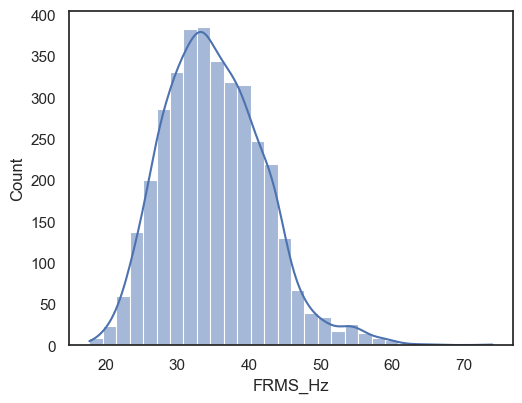

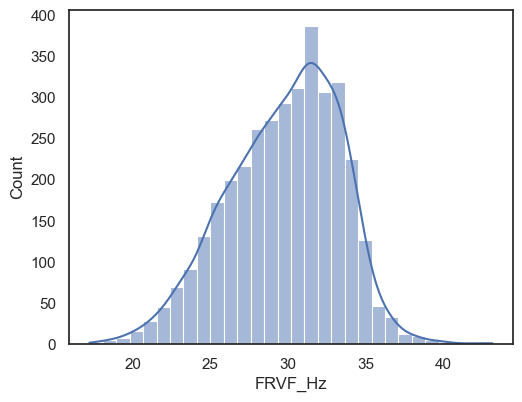

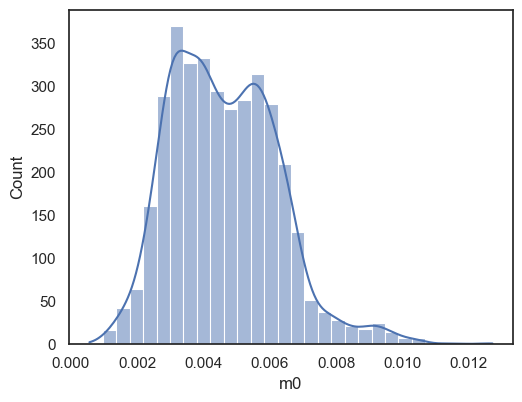

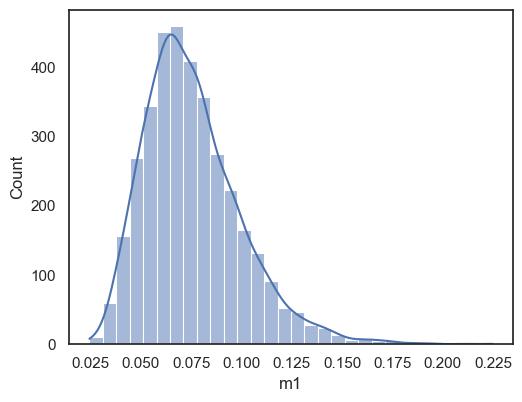

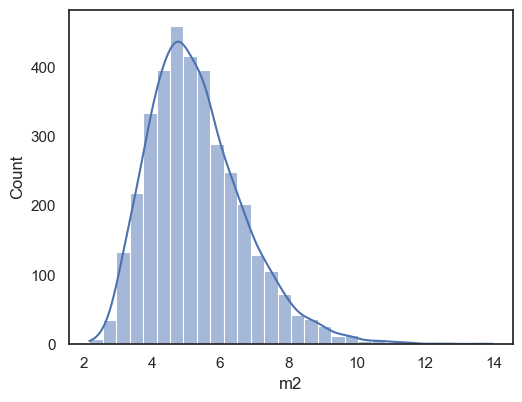

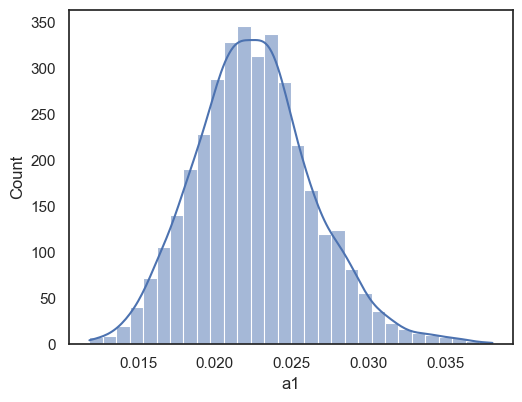

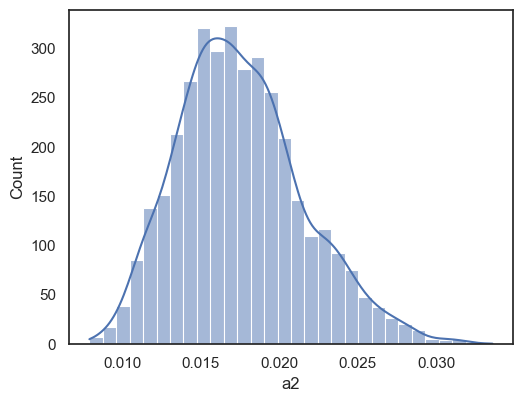

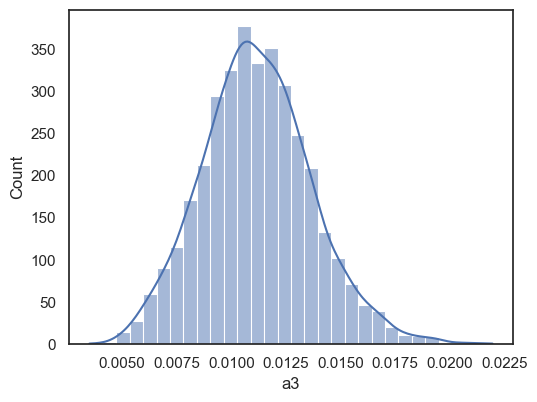

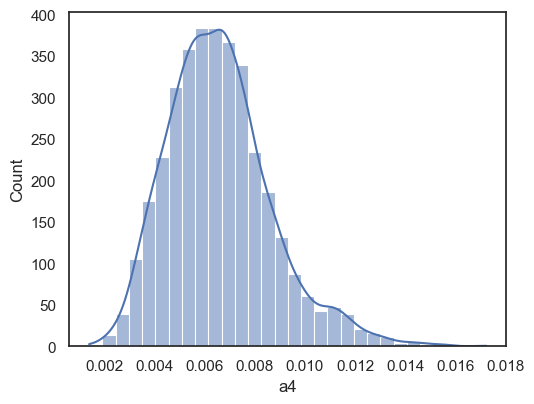

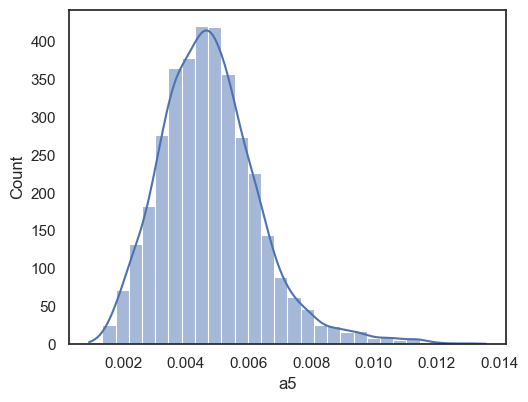

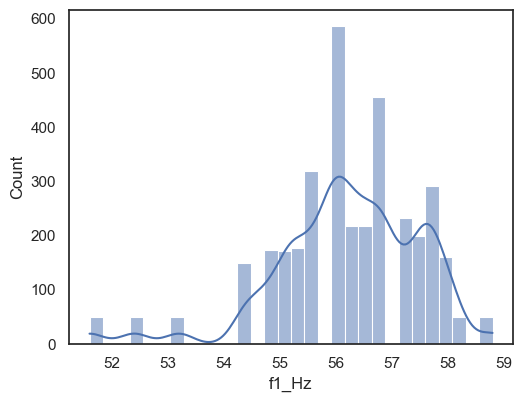

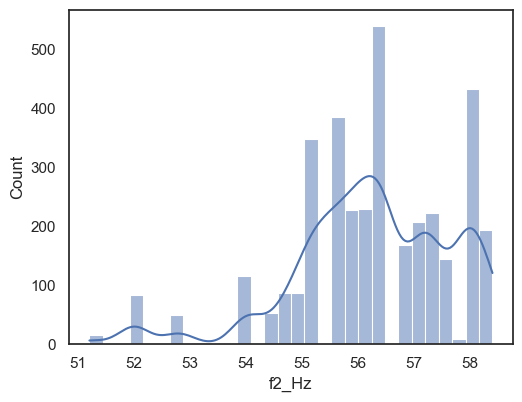

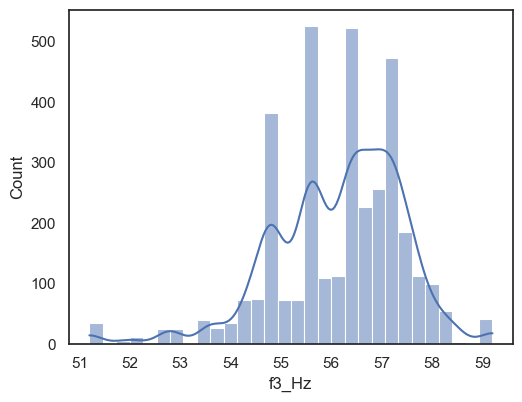

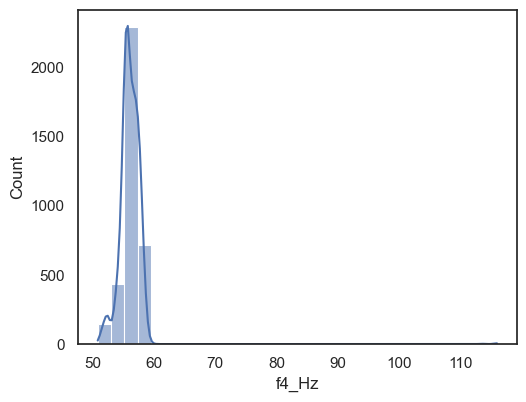

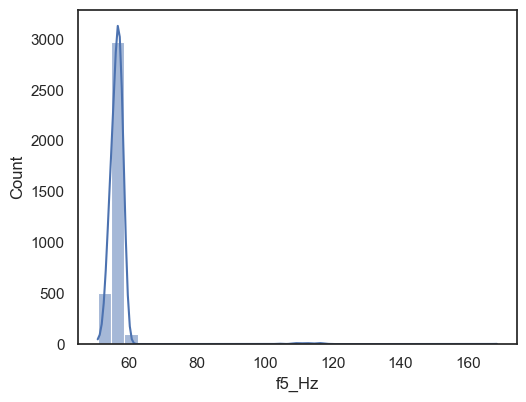

In [23]:
print("Original distributions:")

for i, col in enumerate(df_beam_cols):
    plt.figure(figsize=(10, len(df_beam_cols) * 4))
    plt.subplot(len(df_beam_cols), 2, 2 * i + 1)
    sns.histplot(df_beam_cols[col], kde=True, bins=30)
    plt.tight_layout()
    plt.show()

----------------------------------------------
Dataset splitting
----------------------------------------------
----------------------------------------------

In [24]:
import os, random, numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

# Features
dfX = df_beam_cols.copy()
lbl = labels.copy()
assert (dfX.index == lbl.index).all(), "df_beam_cols and labels must be index-aligned."

# Targets + masks
y_cls  = lbl["target_class"].astype("int32").values
y_crack  = lbl["distance_crack_cm"].astype("float32").values
y_wear = lbl["distance_wear_cm"].astype("float32").values
sw_crack  = lbl["crack_mask"].astype("float32").values
sw_wear = lbl["wear_mask"].astype("float32").values

feature_names = list(dfX.columns)

X_all = dfX[feature_names].astype("float32").values
print(f"[X] Using {len(feature_names)} features.")

X_tr, X_te, \
y_cls_tr, y_cls_te, \
y_crack_tr, y_crack_te, \
y_wear_tr, y_wear_te, \
sw_crack_tr, sw_crack_te, \
sw_wear_tr, sw_wear_te = train_test_split(
    X_all, y_cls, y_crack, y_wear, sw_crack, sw_wear,
    test_size=0.20, random_state=SEED, stratify=y_cls
)

print(f"[Split] train={X_tr.shape[0]}  test={X_te.shape[0]}")

[X] Using 16 features.
[Split] train=2880  test=720


----------------------------------------------
Attribute transformations
----------------------------------------------
----------------------------------------------

In [25]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

cols_yeojohnson = ["FC_Hz","FRVF_Hz","FRMS_Hz","m0","m1","m2","a1","a2","a3","a4","a5"]

cols_present = [c for c in cols_yeojohnson if c in feature_names]
idx_yj = [feature_names.index(c) for c in cols_present]

print(f"[YJ] Requested={len(cols_yeojohnson)}  Present_in_features={len(cols_present)}")
if len(cols_present) > 0:
    print("[YJ] Applying to:", cols_present)

    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr_raw = X_tr.copy()

    Xtr_yj = X_tr[:, idx_yj].astype(np.float64, copy=True)
    Xte_yj = X_te[:, idx_yj].astype(np.float64, copy=True)

    if not np.isfinite(Xtr_yj).all():
        bad = np.where(~np.isfinite(Xtr_yj))
        raise ValueError(f"[YJ] Non-finite values in TRAIN at rows={bad[0][:10]} cols={bad[1][:10]}")
    if not np.isfinite(Xte_yj).all():
        bad = np.where(~np.isfinite(Xte_yj))
        raise ValueError(f"[YJ] Non-finite values in TEST at rows={bad[0][:10]} cols={bad[1][:10]}")

    pt_yj = PowerTransformer(method="yeo-johnson", standardize=False)

    Xtr_yj = pt_yj.fit_transform(Xtr_yj) 
    Xte_yj = pt_yj.transform(Xte_yj)     

    X_tr[:, idx_yj] = Xtr_yj
    X_te[:, idx_yj] = Xte_yj

else:
    print("[YJ] None of the requested columns exist in feature_names. Skipping YJ.")
    pt_yj = None

[YJ] Requested=11  Present_in_features=11
[YJ] Applying to: ['FC_Hz', 'FRVF_Hz', 'FRMS_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5']


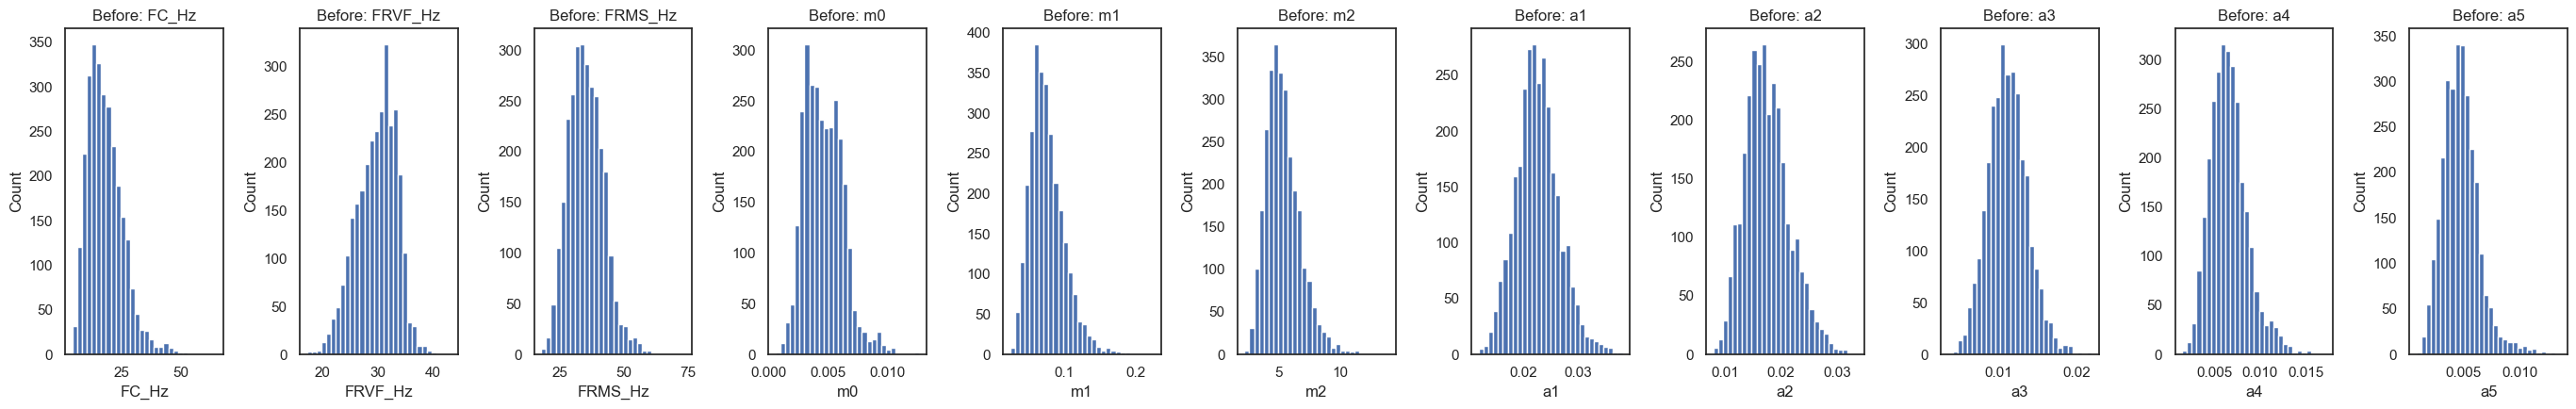

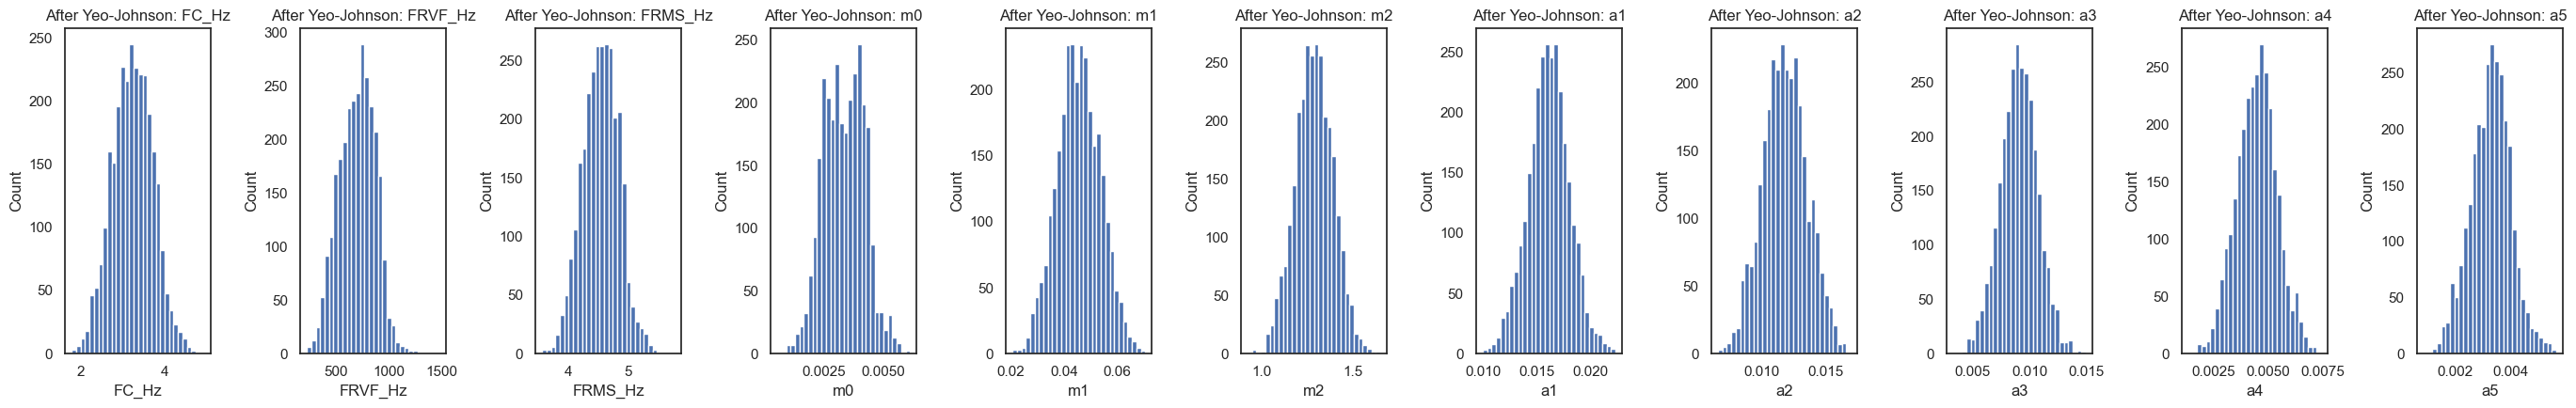

    feature  skew_before  skew_after  abs_reduction
0     FC_Hz     1.056551   -0.001993       1.054558
1        m1     1.054285    0.027622       1.026663
2        m2     0.998801    0.001790       0.997011
3        a5     0.966223   -0.014352       0.951871
4        a4     0.793192    0.006438       0.786754
5        m0     0.642915    0.023544       0.619371
6   FRMS_Hz     0.509830   -0.000368       0.509461
7        a2     0.519547    0.017554       0.501994
8        a1     0.390483   -0.004353       0.386130
9   FRVF_Hz    -0.374309   -0.031823       0.342485
10       a3     0.303779   -0.002868       0.300912


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

sns.set_theme(style="white")

# Histograms (train: before vs after) ----
n = len(cols_present)
fig_w = max(14, 2.5 * n)
fig_h = 4.5

# A) Before
plt.figure(figsize=(fig_w, fig_h))
for i, (c, j) in enumerate(zip(cols_present, idx_yj), start=1):
    ax = plt.subplot(1, n, i)
    ax.hist(X_tr_raw[:, j], bins=30)
    ax.set_title(f"Before: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# B) After
plt.figure(figsize=(fig_w, fig_h))
for i, (c, j) in enumerate(zip(cols_present, idx_yj), start=1):
    ax = plt.subplot(1, n, i)
    ax.hist(X_tr[:, j], bins=30)
    ax.set_title(f"After Yeo-Johnson: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ---- 4) Comparative table of skewness (train) ----
rows = []
for c, j in zip(cols_present, idx_yj):
    sk_before = float(skew(X_tr_raw[:, j], bias=False, nan_policy="omit"))
    sk_after  = float(skew(X_tr[:, j],     bias=False, nan_policy="omit"))
    rows.append({
        "feature": c,
        "skew_before": sk_before,
        "skew_after": sk_after,
        "abs_reduction": abs(sk_before) - abs(sk_after),
    })

df_skew = pd.DataFrame(rows).sort_values("abs_reduction", ascending=False).reset_index(drop=True)

with pd.option_context("display.max_rows", 200, "display.max_columns", 20, "display.width", 160):
    print(df_skew)

[Winsor] Requested=2  Present_in_features=2

=== Winsorize superior (alpha=0.010 -> quantil 0.990) FIT in train ===
Variable Cap_train(q)  Replaced_train %_train
   f4_Hz    58.400002              12   0.42%
   f5_Hz    58.799999              25   0.87%


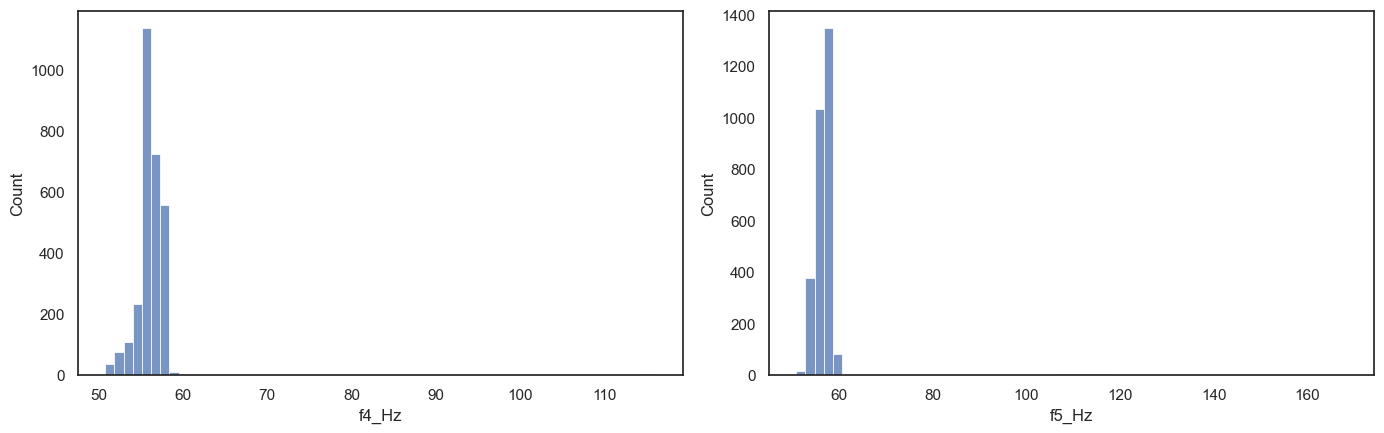

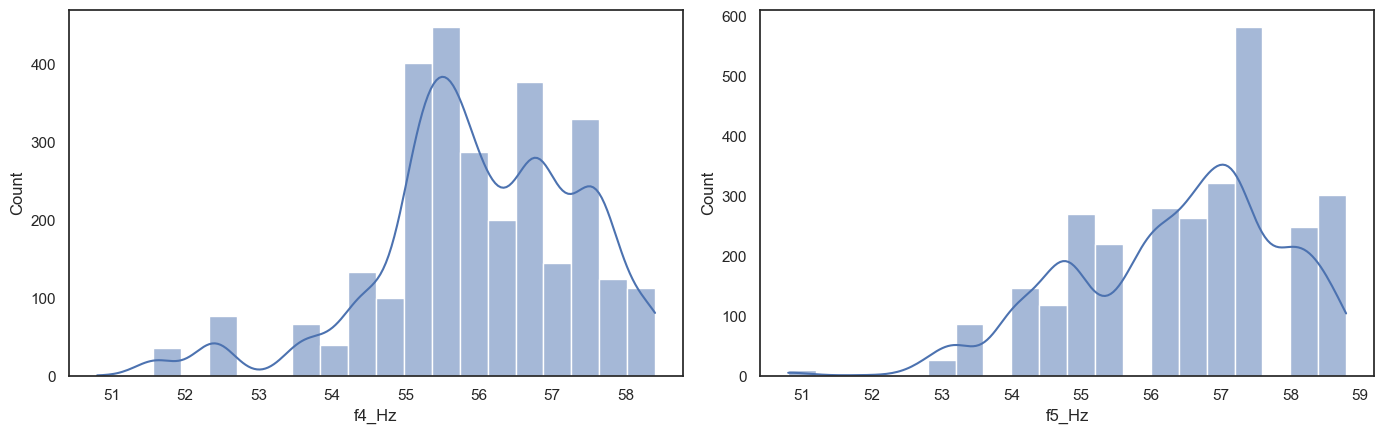

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

UPPER_ALPHA = 0.01
cols_win = ["f4_Hz", "f5_Hz"]

cols_present = [c for c in cols_win if c in feature_names]
idx_win = [feature_names.index(c) for c in cols_present]

print(f"[Winsor] Requested={len(cols_win)}  Present_in_features={len(cols_present)}")
if len(cols_present) == 0:
    print("[Winsor] None of the requested columns exist in feature_names. Skipping.")
else:
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr_win_raw = X_tr[:, idx_win].copy()

    # 1) Thresholds (cap) calculated ONLY in train
    caps = np.quantile(X_tr[:, idx_win], 1.0 - UPPER_ALPHA, axis=0)

    # 2) Apply top winsorize as clipping: x = min(x, cap_train)
    X_tr[:, idx_win] = np.minimum(X_tr[:, idx_win], caps)
    X_te[:, idx_win] = np.minimum(X_te[:, idx_win], caps)

    # 3) Comparative table of replacements (train and test)
    stats = []
    for k, c in enumerate(cols_present):
        cap = float(caps[k])

        tr_before = X_tr_win_raw[:, k]
        tr_after  = X_tr[:, idx_win[k]]

        n_tr = tr_before.size
        n_tr_repl = int(np.sum(tr_before > cap))
        pct_tr = 100.0 * n_tr_repl / n_tr if n_tr else 0.0

        stats.append([c, cap, n_tr_repl, pct_tr])

    df_wins = pd.DataFrame(
        stats,
        columns=["Variable", "Cap_train(q)", "Replaced_train", "%_train"]
    )

    print(f"\n=== Winsorize superior (alpha={UPPER_ALPHA:.3f} -> quantil {1-UPPER_ALPHA:.3f}) FIT in train ===")
    print(df_wins.to_string(index=False, formatters={
        "Cap_train(q)": "{:.6f}".format,
        "%_train": "{:.2f}%".format
    }))

    # 4) Histograms (TRAIN before vs after)
    n = len(cols_present)
    fig_w = max(14, 2.6 * n)
    fig_h = 4.5

    # Before
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))
    if n == 1:
        axes = [axes]

    for ax, (i, c) in zip(axes, enumerate(cols_present)):
        sns.histplot(X_tr_win_raw[:, i], bins=60, ax=ax, kde=False)
        #ax.set_title(f"Train before: {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    # After
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))
    if n == 1:
        axes = [axes]

    for ax, (i, c) in zip(axes, enumerate(cols_present)):
        sns.histplot(X_tr[:, idx_win[i]], bins=20, ax=ax, kde=True)
        #ax.set_title(f"Train after winsorize↑: {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

In [28]:
import numpy as np
import pandas as pd

_req = ["X_tr_raw", "X_tr", "feature_names", "y_cls_tr"]
assert all(v in globals() for v in _req), \
    "Missing variables. Need X_tr_raw (before), X_tr (after), feature_names, y_cls_tr."

df_before = pd.DataFrame(X_tr_raw, columns=feature_names).copy()
df_after  = pd.DataFrame(X_tr,     columns=feature_names).copy()

HUE_COL = "target_class"
df_before[HUE_COL] = y_cls_tr.astype(int)
df_after[HUE_COL]  = y_cls_tr.astype(int)

print("[Pairplot] df_before shape:", df_before.shape)
print("[Pairplot] df_after  shape:", df_after.shape)

[Pairplot] df_before shape: (2880, 17)
[Pairplot] df_after  shape: (2880, 17)


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

def make_pairplot_inline(df, cols, hue, title, sample=500):
    cols_present = [c for c in cols if c in df.columns]
    if len(cols_present) == 0:
        print(f"[Pairplot] Skipping '{title}' (no columns present).")
        return

    d = df[[hue] + cols_present].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(d) == 0:
        print(f"[Pairplot] Skipping '{title}' (no rows after dropna).")
        return

    if len(d) > sample:
        d = d.sample(sample, random_state=42)

    d[hue] = d[hue].astype("category")

    g = sns.pairplot(
        d, vars=cols_present, hue=hue,
        diag_kind="kde",
        kind="scatter",
        height=1.5,
        aspect=1.0,
        plot_kws=dict(s=12, alpha=0.6, edgecolor="none")
    )

    g.fig.suptitle(title, y=1.05, fontsize=12)

    for ax in g.axes.flatten():
        if ax is not None:
            ax.tick_params(labelsize=7)

    if g._legend is not None:
        leg = g._legend

        if hasattr(leg, "legend_handles"):
            handles = leg.legend_handles
        elif hasattr(leg, "legendHandles"):
            handles = leg.legendHandles
        else:
            handles, _ = leg.axes.get_legend_handles_labels()

        labels = [t.get_text() for t in leg.get_texts()]
        n_classes = max(1, len(labels))

        leg.remove()

        g.fig.legend(
            handles, labels,
            title="Class",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=n_classes,
            fontsize=10,
            title_fontsize=8,
            frameon=False
        )

    g.fig.subplots_adjust(
        top=0.97,
        bottom=0.05,
        left=0.05,
        right=0.98,
        wspace=0.02,
        hspace=0.02
    )

    plt.show()

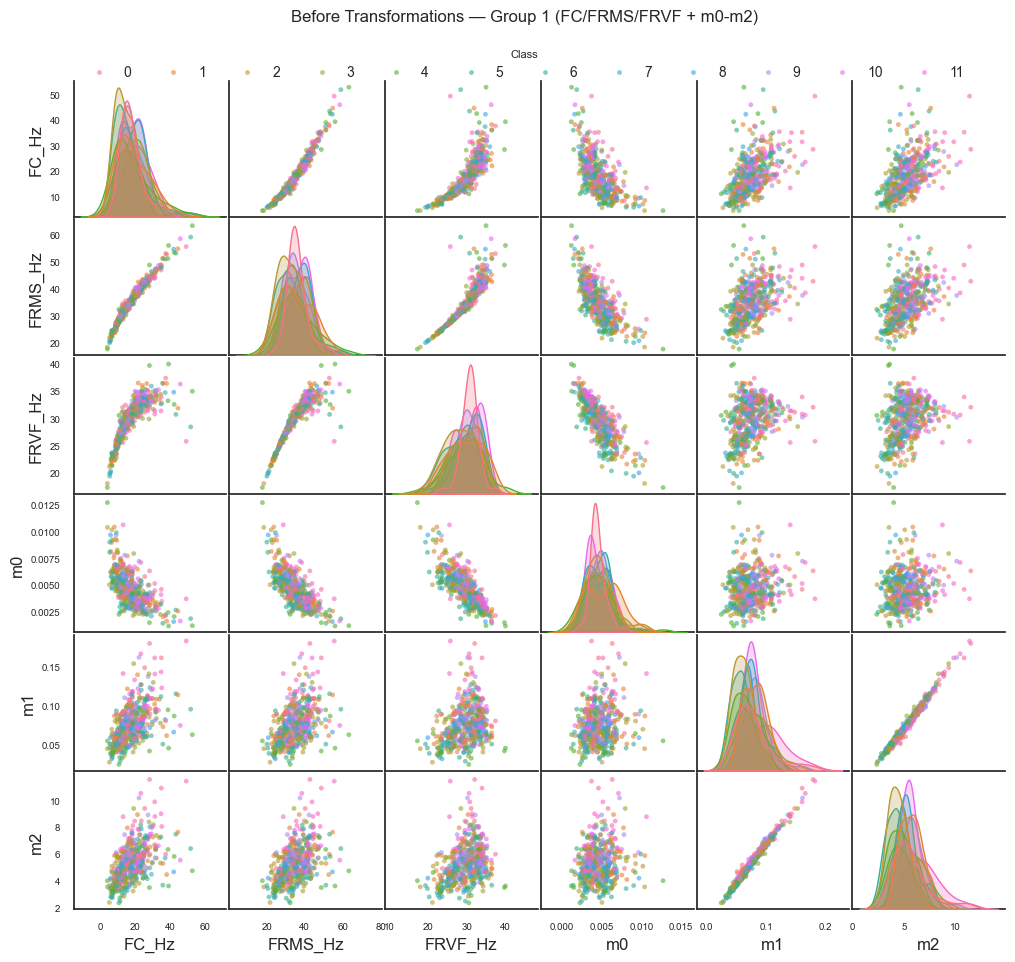

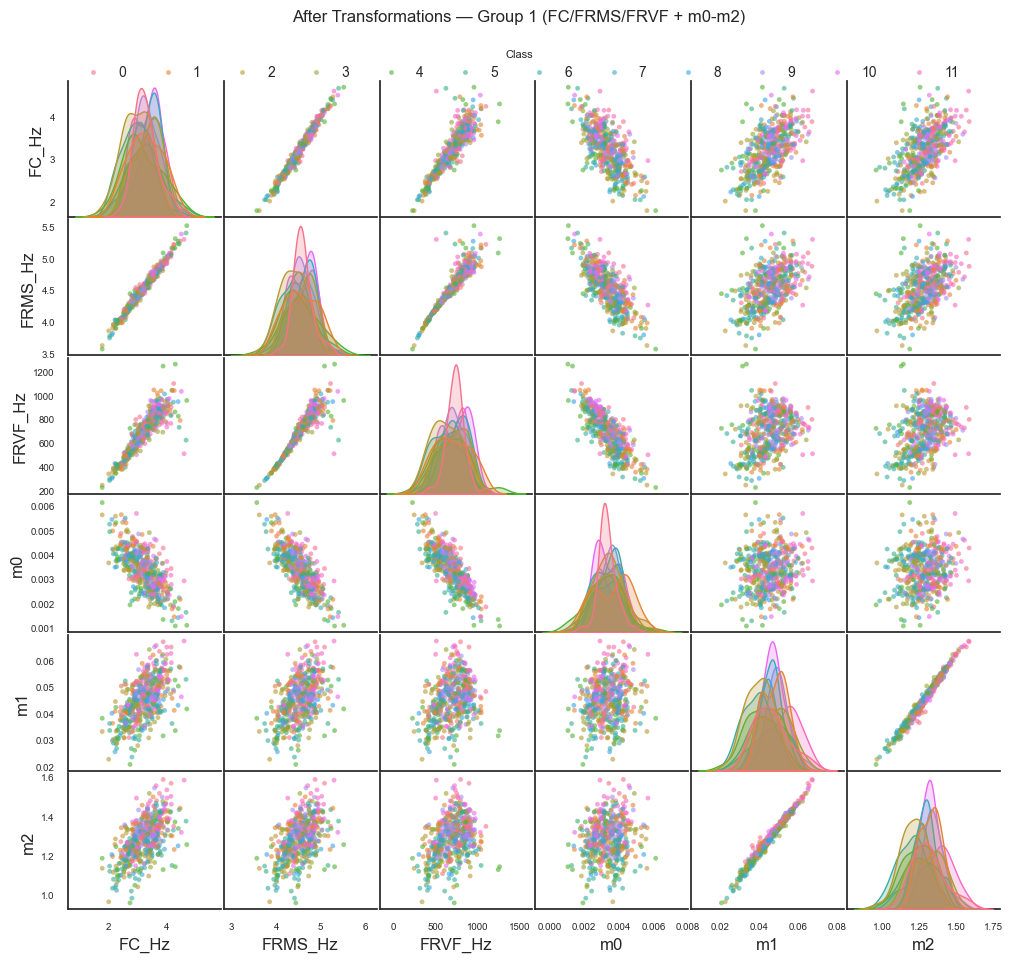

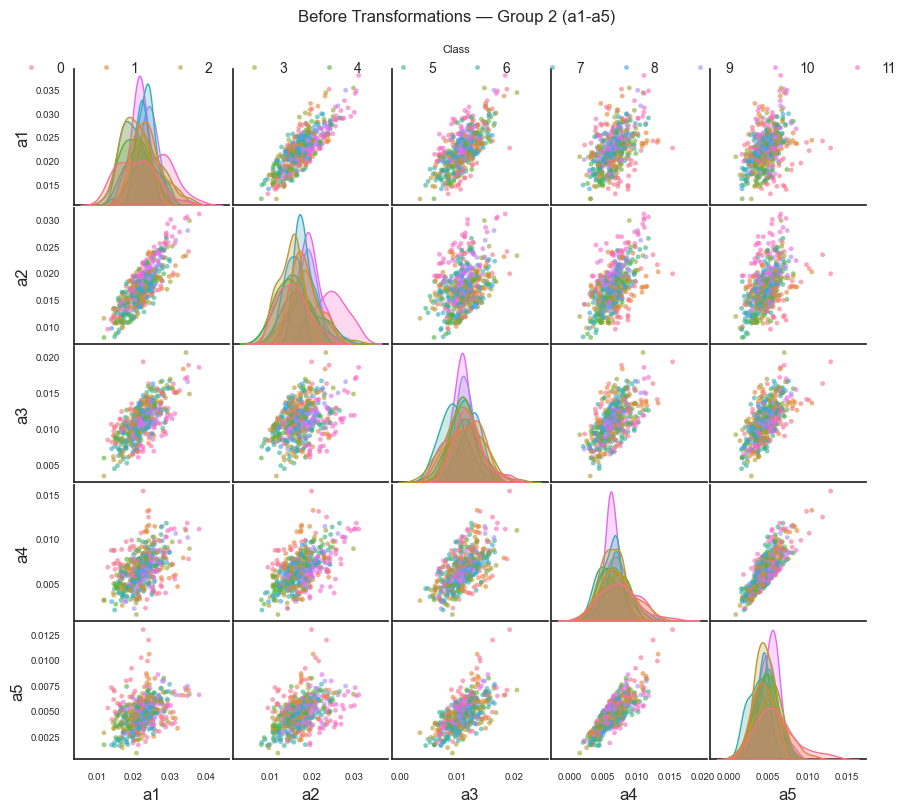

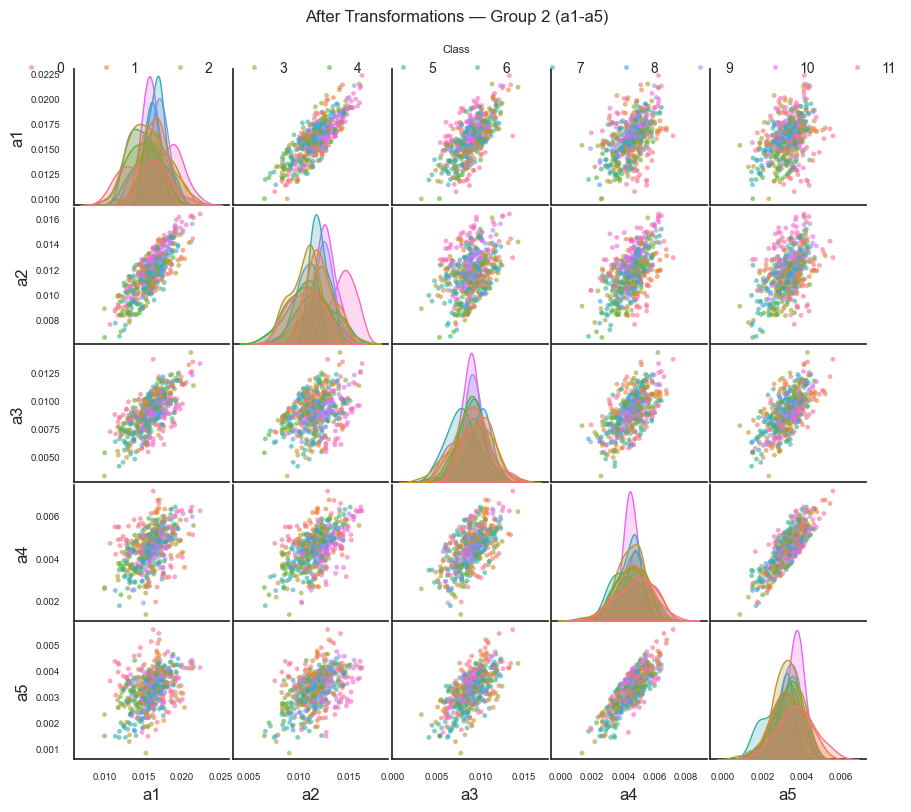

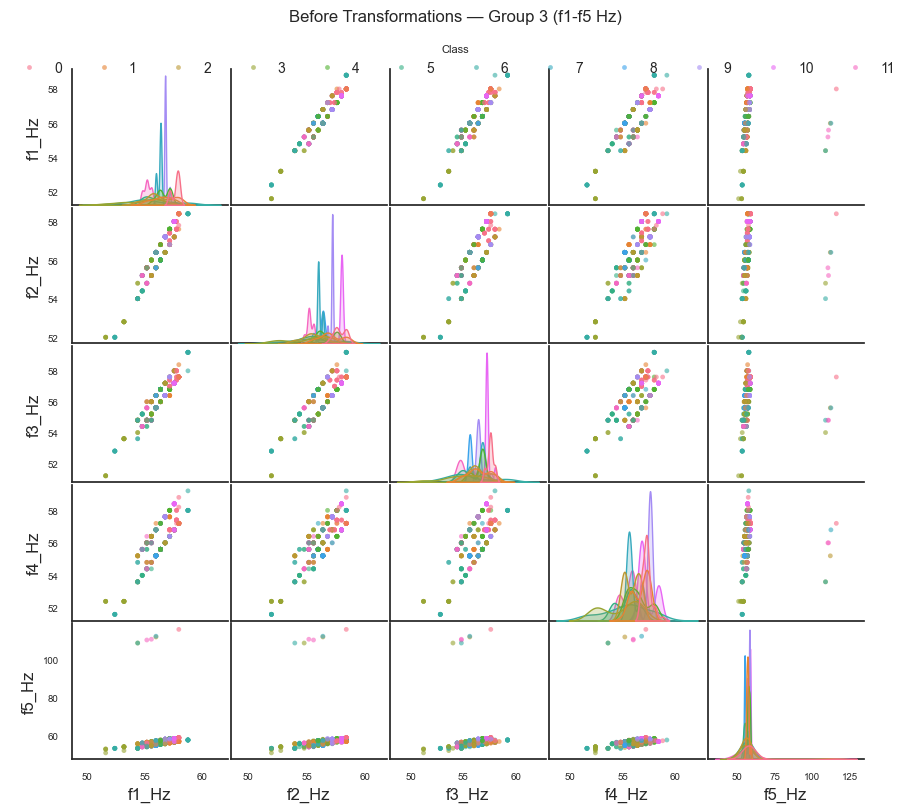

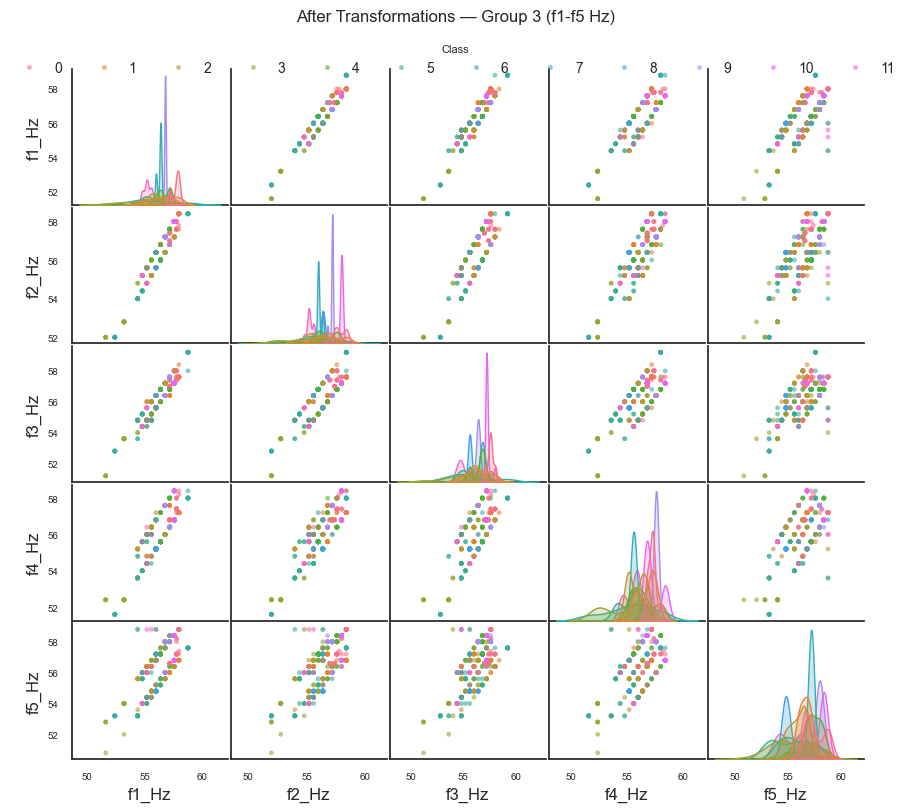

In [30]:
features  = ["FC_Hz","FRMS_Hz","FRVF_Hz","m0","m1","m2"]
features2 = ["a1","a2","a3","a4","a5"]
features3 = ["f1_Hz","f2_Hz","f3_Hz","f4_Hz","f5_Hz"]

groups = {
    "Group 1 (FC/FRMS/FRVF + m0-m2)": features,
    "Group 2 (a1-a5)": features2,
    "Group 3 (f1-f5 Hz)": features3,
}

for name, cols in groups.items():
    make_pairplot_inline(df_before, cols, HUE_COL, f"Before Transformations — {name}", sample=500)
    make_pairplot_inline(df_after,  cols, HUE_COL, f"After Transformations — {name}",  sample=500)

----------------------------------------------
Selection of the Most Relevant Attributes
----------------------------------------------
----------------------------------------------

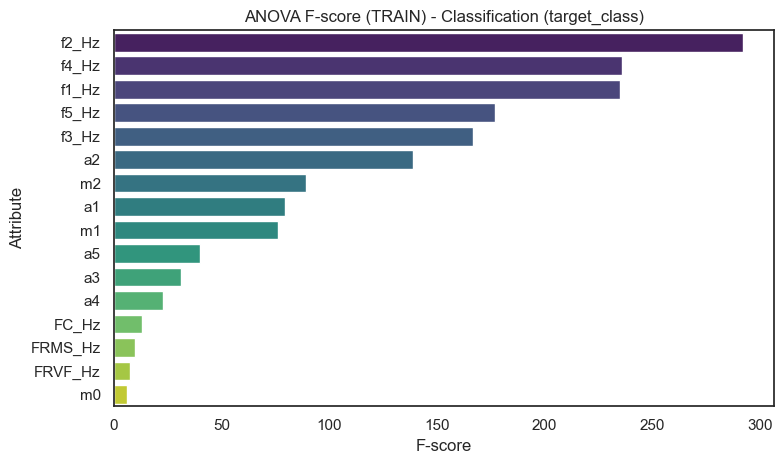

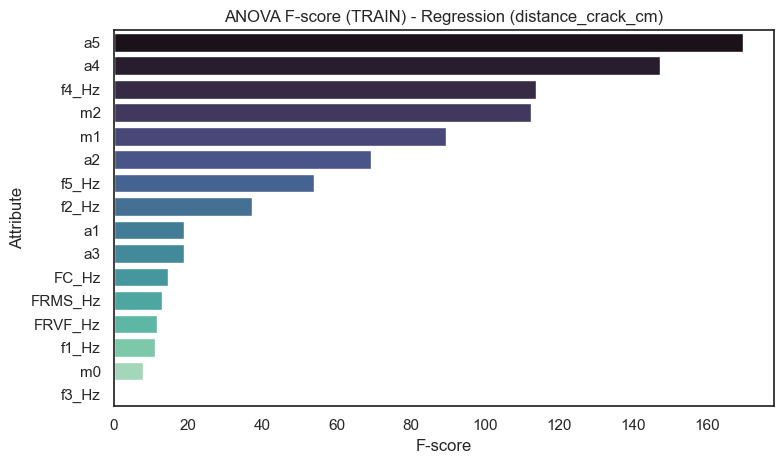

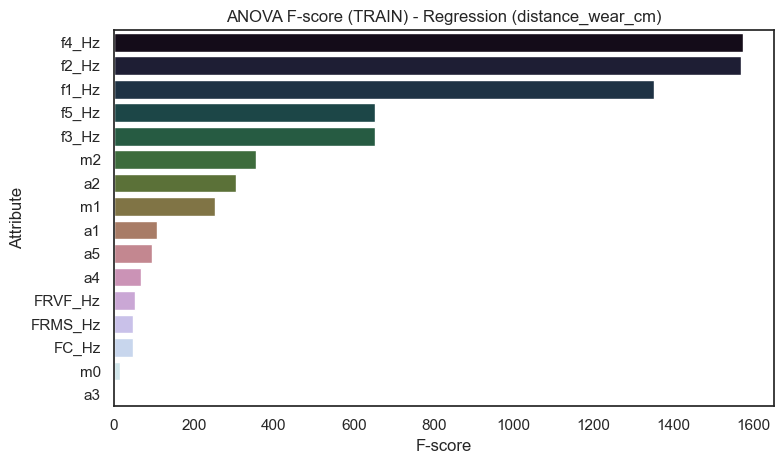

In [31]:
import os, random, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, f_regression

# -------- 1) Selection parameters --------
TOP_K_CLS  = 9
TOP_K_CRACK  = 9
TOP_K_WEAR = 8
USE_P_THRESHOLD = False
P_THRESHOLD = 0.05

PLOT = True

# -------- 2) Utilities --------
def anova_table(X, y, cols, mode="cls"):
    """DataFrame: Attribute, F, p; ordenado por F desc."""
    if mode == "cls":
        F, p = f_classif(X, y)
    else:
        F, p = f_regression(X, y)
    out = pd.DataFrame({"Attribute": cols, "F": F, "p": p})
    return out.sort_values("F", ascending=False).reset_index(drop=True)

def pick_features(df_scores, top_k, use_p=False, p_thr=0.05):
    if use_p:
        sel = df_scores[df_scores["p"] <= p_thr]["Attribute"].tolist()
        if len(sel) == 0:
            sel = df_scores.head(min(top_k, len(df_scores)))["Attribute"].tolist()
    else:
        sel = df_scores.head(min(top_k, len(df_scores)))["Attribute"].tolist()
    return sel

if PLOT:
    import matplotlib.pyplot as plt, seaborn as sns
    def plot_bars(df_scores, title, top_n=25, palette="viridis"):
        dfp = df_scores.head(min(top_n, len(df_scores)))
        plt.figure(figsize=(8, 4.8))
        sns.barplot(data=dfp, x="F", y="Attribute", hue="Attribute", palette=palette, legend=False)
        plt.title(title); plt.xlabel("F-score"); plt.ylabel("Attribute")
        plt.tight_layout(); plt.show()
else:
    def plot_bars(*args, **kwargs):
        pass

# -------- 3) Task-based ANOVA (FIT SOLO TRAIN) --------

# Classification (all train rows)
scores_cls_df = anova_table(X_tr, y_cls_tr, feature_names, mode="cls")
plot_bars(scores_cls_df, "ANOVA F-score (TRAIN) - Classification (target_class)", top_n=25, palette="viridis")

# CRACK Regression (only where there is a valid tag in TRAIN)
mask_crack_tr = sw_crack_tr.astype(bool)
if mask_crack_tr.sum() >= 3:
    scores_crack_df = anova_table(X_tr[mask_crack_tr], y_crack_tr[mask_crack_tr], feature_names, mode="reg")
    plot_bars(scores_crack_df, "ANOVA F-score (TRAIN) - Regression (distance_crack_cm)", top_n=25, palette="mako")
else:
    scores_crack_df = pd.DataFrame({"Attribute": feature_names, "F": np.zeros(len(feature_names)), "p": np.ones(len(feature_names))})

# WEAR Regression (only where there is a valid tag in TRAIN)
mask_wear_tr = sw_wear_tr.astype(bool)
if mask_wear_tr.sum() >= 3:
    scores_wear_df = anova_table(X_tr[mask_wear_tr], y_wear_tr[mask_wear_tr], feature_names, mode="reg")
    plot_bars(scores_wear_df, "ANOVA F-score (TRAIN) - Regression (distance_wear_cm)", top_n=25, palette="cubehelix")
else:
    scores_wear_df = pd.DataFrame({"Attribute": feature_names, "F": np.zeros(len(feature_names)), "p": np.ones(len(feature_names))})

In [32]:
# -------- 4) Selection by task --------
features_cls  = pick_features(scores_cls_df,  TOP_K_CLS,  USE_P_THRESHOLD, P_THRESHOLD)
features_crack  = pick_features(scores_crack_df,  TOP_K_CRACK,  USE_P_THRESHOLD, P_THRESHOLD)
features_wear = pick_features(scores_wear_df, TOP_K_WEAR, USE_P_THRESHOLD, P_THRESHOLD)

print(f"[Selection] Classification ({len(features_cls)}): {features_cls}")
print(f"[Selection] Regression Crack ({len(features_crack)}): {features_crack}")
print(f"[Selection] Regression Wear ({len(features_wear)}): {features_wear}")

# Orderly union without duplicates
union_features = list(dict.fromkeys(features_cls + features_crack + features_wear))
print(f"[UNION] Total number of selected features: {len(union_features)}")
print("[UNION] Features:", union_features)

#--------------------------------------------------------------------------------
# features to remove
MANUAL_DROP = [
    "FRMS_Hz",
    "FRVF_Hz",
    "m0","m1",
]

# Filter only those that actually exist 
drop_present = [f for f in MANUAL_DROP if f in union_features]
drop_missing = [f for f in MANUAL_DROP if f not in union_features]

if len(drop_missing) > 0:
    print("[ManualDrop] Not in union_features (ignored):", drop_missing)

if len(drop_present) > 0:
    print("[ManualDrop] Dropping:", drop_present)

union_features = [f for f in union_features if f not in set(drop_present)]

print(f"[UNION after manual drop] Total selected features: {len(union_features)}")
print("[UNION after manual drop] Features:", union_features)
#--------------------------------------------------------------------------------

idx_union = [feature_names.index(c) for c in union_features]

# Apply selection to train and test (without recalculating anything with test)
X_tr = X_tr[:, idx_union].copy()
X_te = X_te[:, idx_union].copy()

feature_names = union_features

print(f"[X Selected] train={X_tr.shape}  test={X_te.shape}")

[Selection] Classification (9): ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'm1']
[Selection] Regression Crack (9): ['a5', 'a4', 'f4_Hz', 'm2', 'm1', 'a2', 'f5_Hz', 'f2_Hz', 'a1']
[Selection] Regression Wear (8): ['f4_Hz', 'f2_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'm2', 'a2', 'm1']
[UNION] Total number of selected features: 11
[UNION] Features: ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'm1', 'a5', 'a4']
[ManualDrop] Not in union_features (ignored): ['FRMS_Hz', 'FRVF_Hz', 'm0']
[ManualDrop] Dropping: ['m1']
[UNION after manual drop] Total selected features: 10
[UNION after manual drop] Features: ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'a5', 'a4']
[X Selected] train=(2880, 10)  test=(720, 10)


----------------------------------------------
Data Normalization
----------------------------------------------
----------------------------------------------

In [33]:
from sklearn.preprocessing import RobustScaler

X_tr = X_tr.copy()
X_te = X_te.copy()

scaler = RobustScaler(
    with_centering=True,
    with_scaling=True,
    quantile_range=(25.0, 75.0) 
)

# Fit ONLY in training
X_tr = scaler.fit_transform(X_tr)

# Transform in test using parameters from train
X_te = scaler.transform(X_te)

print("[Scaler] RobustScaler fitted on TRAIN and applied to TRAIN/TEST")
print(f"[Scaler] Shapes -> train={X_tr.shape}  test={X_te.shape}")

[Scaler] RobustScaler fitted on TRAIN and applied to TRAIN/TEST
[Scaler] Shapes -> train=(2880, 10)  test=(720, 10)


----------------------------------------------
Hyperparameter Tuning
----------------------------------------------
----------------------------------------------

In [ ]:
# ============================================================
# Single-task models (classification) + GRIDSEARCHCV
# Export: best models (.pkl) + summary table (CSV)
# ============================================================

import os, numpy as np, pandas as pd, joblib
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# -----------------------------
# 0) Variable verification
# -----------------------------
_req = ["X_tr","X_te","y_cls_tr","y_cls_te","SEED"]
assert all(v in globals() for v in _req), \
    "Missing variables. Run your preprocessing cells first (X_tr/X_te/y_cls_tr/y_cls_te/SEED)."

X_train = np.asarray(X_tr)
X_test  = np.asarray(X_te)
y_train = np.asarray(y_cls_tr).astype(int)
y_test  = np.asarray(y_cls_te).astype(int)

n_classes = int(np.unique(y_train).size)
print(f"[Data] X_train={X_train.shape} X_test={X_test.shape}  n_classes={n_classes}")

# ---------------------------------------------------------
# 1) Cross-validation) - 10 folds
# ---------------------------------------------------------
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# ---------------------------------------------------------
# 2) Define models and grids
# ---------------------------------------------------------
models_and_grids = {
    "LogReg": (
        Pipeline([("clf", LogisticRegression())]),
        {
            "clf__C": [0.01, 0.1, 1, 10, 100],
            "clf__solver": ["liblinear", "lbfgs", "saga"],
            "clf__max_iter": [200, 500, 1000],
            "clf__class_weight": [None, "balanced"],
            "clf__penalty": ["l2"],
        }
    ),

    "GaussianNB": (
        Pipeline([("clf", GaussianNB())]),
        {
            "clf__var_smoothing": np.logspace(-12, -6, 13),
        }
    ),

    "KNN": (
        Pipeline([("clf", KNeighborsClassifier())]),
        {
            "clf__n_neighbors": [11, 13, 15, 21, 29, 41, 61],
            "clf__weights": ["uniform"],    
            "clf__metric": ["euclidean", "manhattan", "minkowski", "chebyshev"],
            "clf__p": [1, 2], 
        }
    ),

    "SVM": (
        Pipeline([("clf", SVC(probability=False))]),
        {
            "clf__C": [0.01, 0.1, 1, 10, 100],
            "clf__kernel": ["linear", "rbf", "poly", "sigmoid"],
            "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
            "clf__degree": [3, 4, 5],
            "clf__class_weight": [None, "balanced"],
        }
    ),

    "DecisionTree": (
        Pipeline([("clf", DecisionTreeClassifier(random_state=SEED))]),
        {
            "clf__max_depth": [2, 3, 4, 5, 6],
            "clf__min_samples_split": [5, 10, 20],
            "clf__min_samples_leaf": [5, 10, 20],
            "clf__max_features": ["sqrt", "log2"], 
            "clf__ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],
            "clf__criterion": ["gini", "entropy"],
            "clf__splitter": ["best", "random"],
        }
    ),

    "MLP": (
        Pipeline([("clf", MLPClassifier(max_iter=300, random_state=SEED))]),
        {
            "clf__hidden_layer_sizes": [(10,), (50,), (100,), (10, 50), (50, 100), (50, 50), (10, 10, 10)],
            "clf__activation": ["relu", "tanh", "logistic"],
            "clf__solver": ["adam", "sgd"],
            "clf__alpha": [0.0001, 0.001, 0.01],
            "clf__learning_rate": ["constant"],
        }
    ),
}

# ---------------------------------------------------------
# 3) Train GridSearch for each model
# scoring: accuracy
# ---------------------------------------------------------
RESULTS_DIR = "cls_grid_models"
os.makedirs(RESULTS_DIR, exist_ok=True)

rows = []
best_models = {}

for name, (pipe, grid) in models_and_grids.items():
    print("\n" + "="*70)
    print(f"[GridSearch] {name}")
    print("="*70)

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="accuracy",
        cv=cv10,
        n_jobs=-1,
        verbose=1,
        refit=True,
        return_train_score=False
    )

    gs.fit(X_train, y_train)

    print(f"[{name}] Best CV accuracy: {gs.best_score_:.4f}")
    print(f"[{name}] Best params: {gs.best_params_}")

    best_est = gs.best_estimator_
    best_models[name] = best_est

    # --- Test evaluation
    y_pred = best_est.predict(X_test)
    acc_te = accuracy_score(y_test, y_pred)

    print(f"[{name}] TEST accuracy: {acc_te:.4f}")
    print(f"[{name}] Classification report (TEST):\n")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    # Save model
    out_pkl = os.path.join(RESULTS_DIR, f"best_{name}_cls.pkl")
    joblib.dump(best_est, out_pkl)
    print(f"[{name}] Model exported -> {out_pkl}")

    # Record results
    rows.append({
        "model": name,
        "best_cv_acc": float(gs.best_score_),
        "test_acc": float(acc_te),
        "best_params": str(gs.best_params_),
        "model_path": out_pkl,
        "confusion_matrix": cm.tolist(),
    })

# ---------------------------------------------------------
# 4) Summary table (ordered by test_acc)
# ---------------------------------------------------------
df_results = pd.DataFrame(rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("[SUMMARY] Models ranked by TEST accuracy")
print("="*70)
with pd.option_context("display.max_colwidth", 200, "display.width", 200):
    print(df_results[["model","best_cv_acc","test_acc","model_path","best_params"]])

out_csv = os.path.join(RESULTS_DIR, "classification_grid_results.csv")
df_results.to_csv(out_csv, index=False)
print(f"\n[SUMMARY] Results exported -> {out_csv}")

# ---------------------------------------------------------
# 5) Best final model (according to TEST)
# ---------------------------------------------------------
best_name = df_results.loc[0, "model"]
best_final = best_models[best_name]
print("\n" + "="*70)
print(f"[BEST] Best model by TEST accuracy: {best_name}")
print("="*70)
print(best_final)

[Data] X_train=(2880, 10) X_test=(720, 10)  n_classes=12

[GridSearch] LogReg
Fitting 10 folds for each of 90 candidates, totalling 900 fits
[LogReg] Best CV accuracy: 0.5920
[LogReg] Best params: {'clf__C': 10, 'clf__class_weight': None, 'clf__max_iter': 200, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
[LogReg] TEST accuracy: 0.5319
[LogReg] Classification report (TEST):

              precision    recall  f1-score   support

           0     0.7931    0.7667    0.7797        60
           1     0.3621    0.3500    0.3559        60
           2     0.3889    0.4667    0.4242        60
           3     0.3878    0.3167    0.3486        60
           4     0.1887    0.1667    0.1770        60
           5     0.3333    0.1833    0.2366        60
           6     0.3947    0.2500    0.3061        60
           7     0.5190    0.6833    0.5899        60
           8     0.5135    0.6333    0.5672        60
           9     0.6377    0.7333    0.6822        60
          10     0.8462    

c:\Users\axelr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


[TEST] Samples=720  Features=10  Classes=12

[Logistic Regression] Classification report (TEST)
              precision    recall  f1-score   support

           0     0.7931    0.7667    0.7797        60
           1     0.3621    0.3500    0.3559        60
           2     0.3889    0.4667    0.4242        60
           3     0.3878    0.3167    0.3486        60
           4     0.1887    0.1667    0.1770        60
           5     0.3333    0.1833    0.2366        60
           6     0.3947    0.2500    0.3061        60
           7     0.5190    0.6833    0.5899        60
           8     0.5135    0.6333    0.5672        60
           9     0.6377    0.7333    0.6822        60
          10     0.8462    0.9167    0.8800        60
          11     0.7639    0.9167    0.8333        60

    accuracy                         0.5319       720
   macro avg     0.5107    0.5319    0.5151       720
weighted avg     0.5107    0.5319    0.5151       720



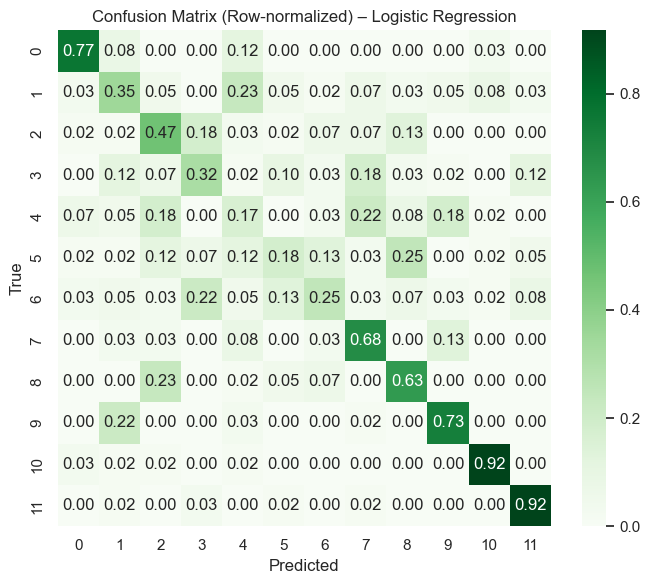


[Naive Bayes] Classification report (TEST)
              precision    recall  f1-score   support

           0     0.7313    0.8167    0.7717        60
           1     0.4444    0.4000    0.4211        60
           2     0.6364    0.3500    0.4516        60
           3     0.5814    0.4167    0.4854        60
           4     0.4528    0.4000    0.4248        60
           5     0.6512    0.4667    0.5437        60
           6     0.4103    0.2667    0.3232        60
           7     0.7164    0.8000    0.7559        60
           8     0.6452    1.0000    0.7843        60
           9     0.8906    0.9500    0.9194        60
          10     0.8056    0.9667    0.8788        60
          11     0.6304    0.9667    0.7632        60

    accuracy                         0.6500       720
   macro avg     0.6330    0.6500    0.6269       720
weighted avg     0.6330    0.6500    0.6269       720



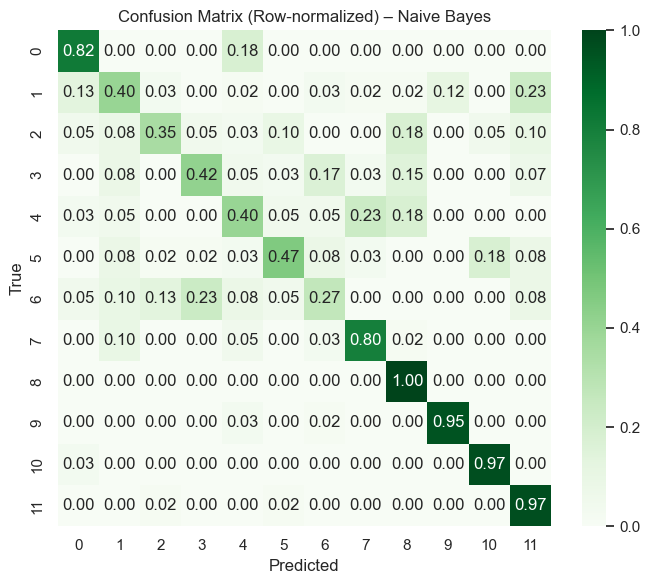


[KNN] Classification report (TEST)
              precision    recall  f1-score   support

           0     0.9344    0.9500    0.9421        60
           1     0.9107    0.8500    0.8793        60
           2     0.8254    0.8667    0.8455        60
           3     0.8947    0.8500    0.8718        60
           4     0.9737    0.6167    0.7551        60
           5     0.9655    0.9333    0.9492        60
           6     0.9322    0.9167    0.9244        60
           7     0.7973    0.9833    0.8806        60
           8     0.8310    0.9833    0.9008        60
           9     0.9194    0.9500    0.9344        60
          10     0.9672    0.9833    0.9752        60
          11     0.9833    0.9833    0.9833        60

    accuracy                         0.9056       720
   macro avg     0.9112    0.9056    0.9035       720
weighted avg     0.9112    0.9056    0.9035       720



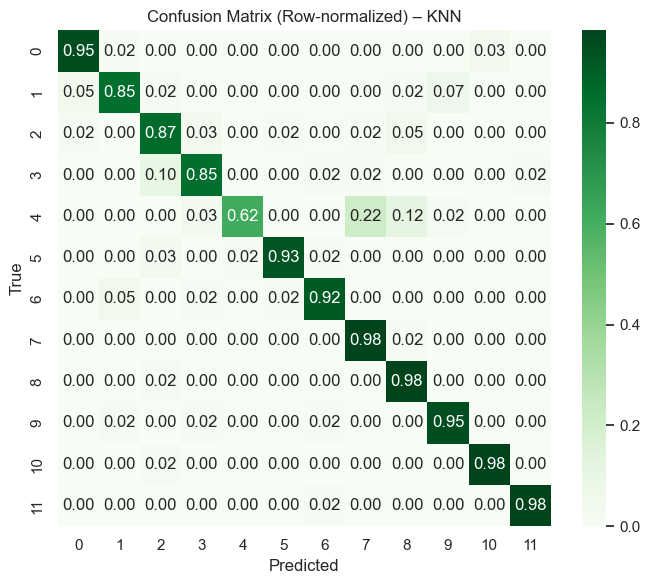


[SVM] Classification report (TEST)
              precision    recall  f1-score   support

           0     0.9831    0.9667    0.9748        60
           1     0.8769    0.9500    0.9120        60
           2     0.8833    0.8833    0.8833        60
           3     0.9000    0.9000    0.9000        60
           4     0.9184    0.7500    0.8257        60
           5     0.9828    0.9500    0.9661        60
           6     0.9322    0.9167    0.9244        60
           7     0.9344    0.9500    0.9421        60
           8     0.8788    0.9667    0.9206        60
           9     0.9667    0.9667    0.9667        60
          10     0.9524    1.0000    0.9756        60
          11     0.9833    0.9833    0.9833        60

    accuracy                         0.9319       720
   macro avg     0.9327    0.9319    0.9312       720
weighted avg     0.9327    0.9319    0.9312       720



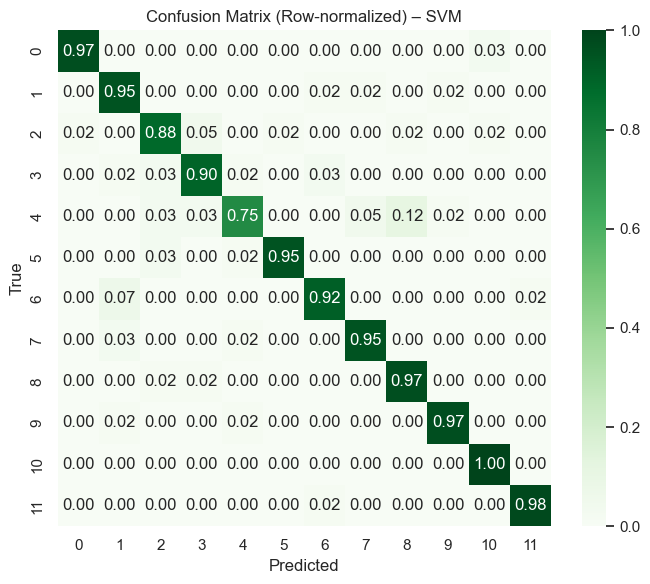


[Decision Tree] Classification report (TEST)
              precision    recall  f1-score   support

           0     0.8824    1.0000    0.9375        60
           1     0.7027    0.4333    0.5361        60
           2     0.3939    0.8667    0.5417        60
           3     0.7000    0.8167    0.7538        60
           4     0.9545    0.3500    0.5122        60
           5     0.9189    0.5667    0.7010        60
           6     0.7742    0.4000    0.5275        60
           7     0.7606    0.9000    0.8244        60
           8     0.8000    0.6667    0.7273        60
           9     0.8676    0.9833    0.9219        60
          10     0.9355    0.9667    0.9508        60
          11     0.8056    0.9667    0.8788        60

    accuracy                         0.7431       720
   macro avg     0.7913    0.7431    0.7344       720
weighted avg     0.7913    0.7431    0.7344       720



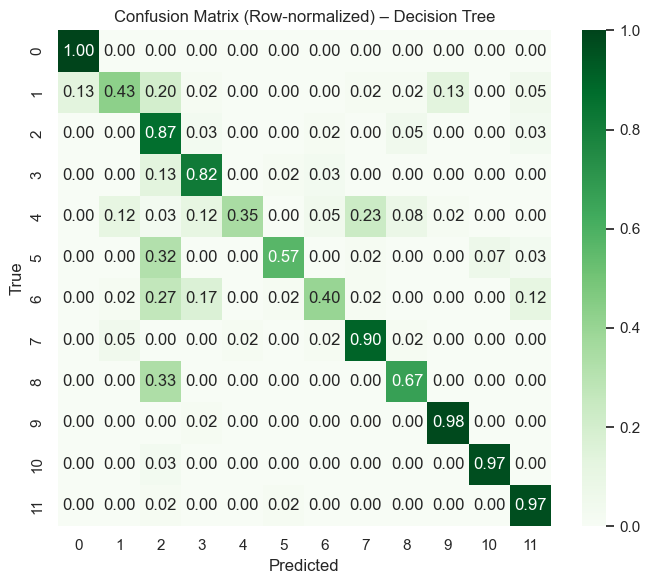


[MLP] Classification report (TEST)
              precision    recall  f1-score   support

           0     1.0000    0.9500    0.9744        60
           1     0.9516    0.9833    0.9672        60
           2     0.9821    0.9167    0.9483        60
           3     1.0000    0.9667    0.9831        60
           4     0.9310    0.9000    0.9153        60
           5     0.9825    0.9333    0.9573        60
           6     0.9062    0.9667    0.9355        60
           7     0.9667    0.9667    0.9667        60
           8     0.9375    1.0000    0.9677        60
           9     1.0000    0.9833    0.9916        60
          10     0.9219    0.9833    0.9516        60
          11     0.9508    0.9667    0.9587        60

    accuracy                         0.9597       720
   macro avg     0.9609    0.9597    0.9598       720
weighted avg     0.9609    0.9597    0.9598       720



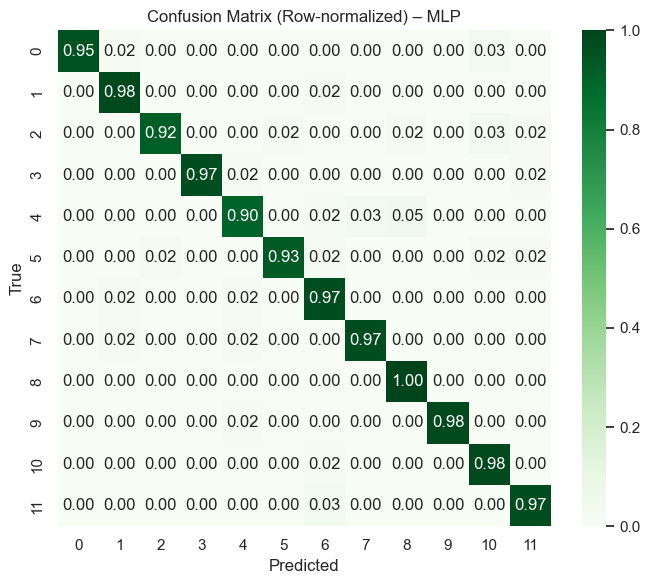


[SUMMARY] Test metrics (sorted by F1-score)
                     Accuracy  Precision (weighted)  Recall (weighted)  F1-score (weighted)
MLP                  0.959722              0.960863           0.959722             0.959766
SVM                  0.931944              0.932686           0.931944             0.931223
KNN                  0.905556              0.911239           0.905556             0.903478
Decision Tree        0.743056              0.791325           0.743056             0.734415
Naive Bayes          0.650000              0.632999           0.650000             0.626915
Logistic Regression  0.531944              0.510733           0.531944             0.515061

[Export] classification_test_metrics.csv saved


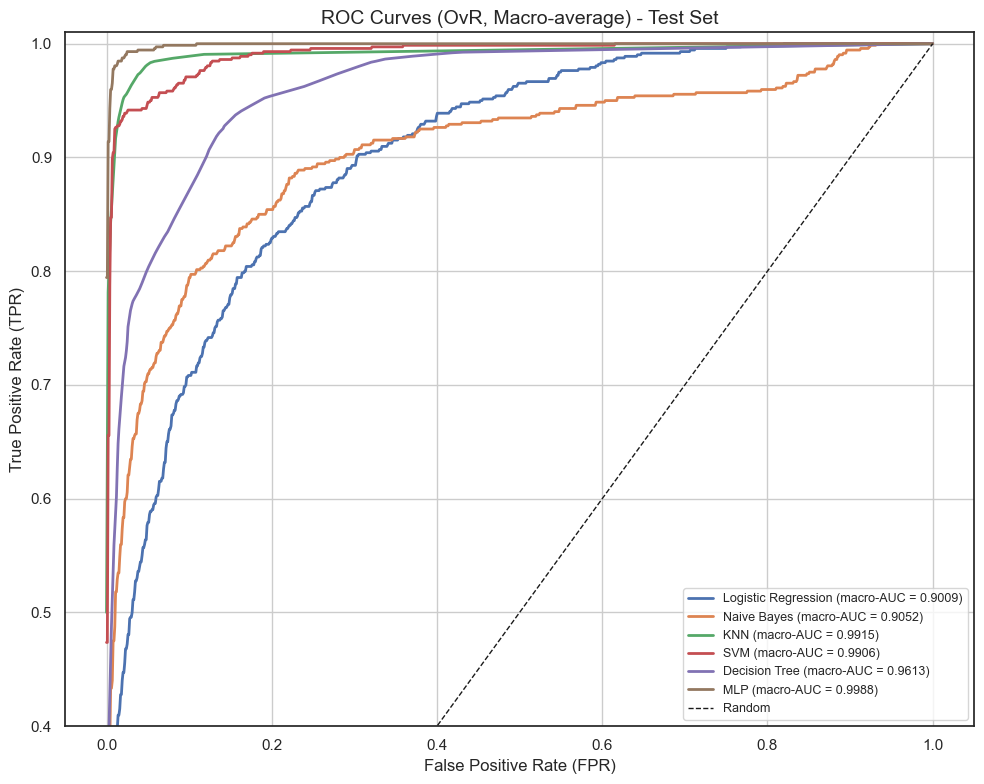

In [35]:
# ============================================================
# EVALUATION OF CLASSIFICATION MODELS (TEST SET)
# + Row-normalized confusion matrix by model
# ============================================================

import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# 0) Verificación de variables
# ------------------------------------------------------------
_req = ["X_te", "y_cls_te"]
assert all(v in globals() for v in _req), \
    "Missing variables. Ensure X_te and y_cls_te are available."

X_test = np.asarray(X_te)
y_test = np.asarray(y_cls_te).astype(int)

classes = np.unique(y_test)
n_classes = len(classes)

print(f"[TEST] Samples={X_test.shape[0]}  Features={X_test.shape[1]}  Classes={n_classes}")

# ------------------------------------------------------------
# 1) Load trained models
# ------------------------------------------------------------
MODELS_DIR = "cls_grid_models"

models = {
    "Logistic Regression": joblib.load(os.path.join(MODELS_DIR, "best_LogReg_cls.pkl")),
    "Naive Bayes": joblib.load(os.path.join(MODELS_DIR, "best_GaussianNB_cls.pkl")),
    "KNN": joblib.load(os.path.join(MODELS_DIR, "best_KNN_cls.pkl")),
    "SVM": joblib.load(os.path.join(MODELS_DIR, "best_SVM_cls.pkl")),
    "Decision Tree": joblib.load(os.path.join(MODELS_DIR, "best_DecisionTree_cls.pkl")),
    "MLP": joblib.load(os.path.join(MODELS_DIR, "best_MLP_cls.pkl")),
}

# ------------------------------------------------------------
# Helper: Plot confusion matrix (row-normalized) in green style
# ------------------------------------------------------------
import seaborn as sns
def plot_confusion_matrix_row_normalized(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    # Row-normalization
    cm_row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm,
        cm_row_sum,
        out=np.zeros_like(cm, dtype=float),
        where=(cm_row_sum != 0)
    )

    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        cbar=True
    )

    plt.title(title, fontsize=12)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 2) Global metrics + Report + Normalized confusion matrix
# ------------------------------------------------------------
metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    print("\n" + "="*70)
    print(f"[{name}] Classification report (TEST)")
    print("="*70)
    print(classification_report(y_test, y_pred, digits=4))

    # --- Confusion matrix (row-normalized) ---
    plot_confusion_matrix_row_normalized(
        y_true=y_test,
        y_pred=y_pred,
        title=f"Confusion Matrix (Row-normalized) – {name}"
    )

# Summary table
df_metrics = pd.DataFrame(metrics).T.sort_values("F1-score (weighted)", ascending=False)
print("\n" + "="*70)
print("[SUMMARY] Test metrics (sorted by F1-score)")
print("="*70)
with pd.option_context("display.width", 160):
    print(df_metrics)

# Save table
df_metrics.to_csv(os.path.join(MODELS_DIR, "classification_test_metrics.csv"))
print("\n[Export] classification_test_metrics.csv saved")

# ------------------------------------------------------------
# 3) ROC curves (multiclass, OvR) – MACRO AVERAGE
# ------------------------------------------------------------
from numpy import interp

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"[ROC] {name} does not support probability/decision scores. Skipped.")
        continue

    fpr_dict = {}
    tpr_dict = {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

    fpr_common = np.linspace(0, 1, 1000)

    tpr_interp = np.zeros_like(fpr_common)

    for i in range(n_classes):
        tpr_interp += interp(fpr_common, fpr_dict[i], tpr_dict[i])

    tpr_macro = tpr_interp / n_classes
    auc_macro = auc(fpr_common, tpr_macro)

    plt.plot(
        fpr_common,
        tpr_macro,
        linewidth=2,
        label=f"{name} (macro-AUC = {auc_macro:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")

plt.title("ROC Curves (OvR, Macro-average) - Test Set", fontsize=14)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.ylim(0.40, 1.01)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

[TRAIN] Samples=2880  Features=10  Classes=12

[Logistic Regression] Classification report (TRAIN)
              precision    recall  f1-score   support

           0     0.7638    0.8625    0.8102       240
           1     0.4675    0.4500    0.4586       240
           2     0.5075    0.7042    0.5899       240
           3     0.4056    0.3042    0.3476       240
           4     0.3820    0.2833    0.3254       240
           5     0.5079    0.2667    0.3497       240
           6     0.3937    0.2625    0.3150       240
           7     0.5810    0.7917    0.6702       240
           8     0.6098    0.7750    0.6826       240
           9     0.7215    0.7125    0.7170       240
          10     0.8008    0.8708    0.8343       240
          11     0.8044    0.9083    0.8532       240

    accuracy                         0.5993      2880
   macro avg     0.5788    0.5993    0.5795      2880
weighted avg     0.5788    0.5993    0.5795      2880


[Naive Bayes] Classification repo

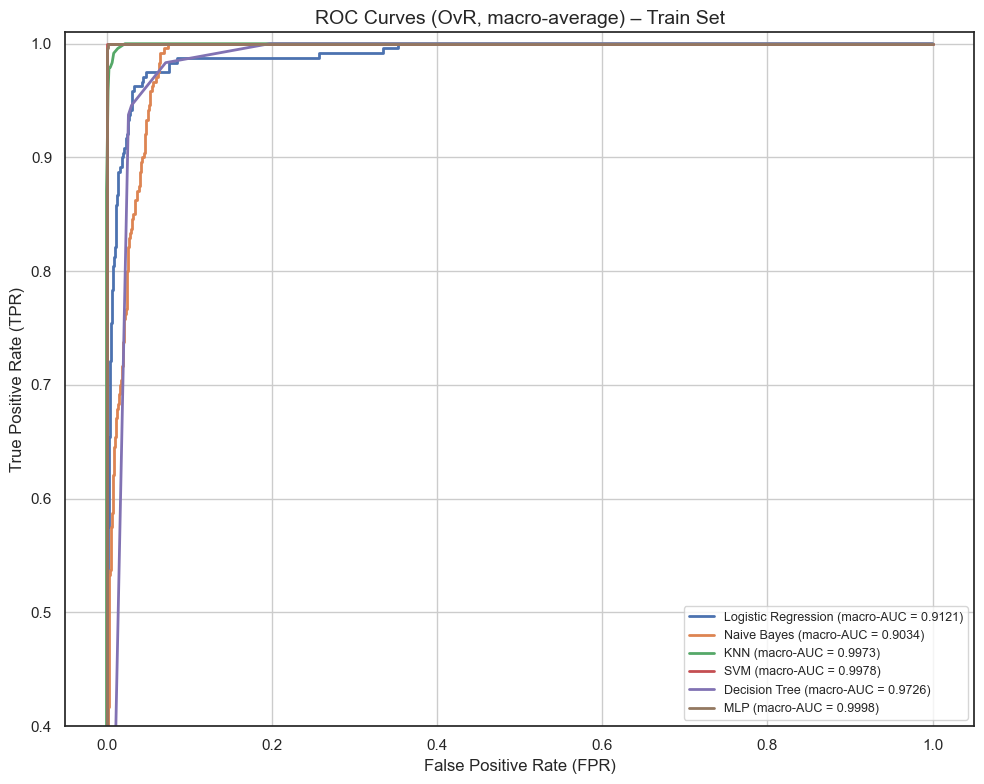

In [36]:
# ============================================================
# EVALUATION OF CLASSIFICATION MODELS (TRAIN SET)
# (to compare vs TEST and detect overfitting)
# ============================================================

import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# 0) Variable verification
# ------------------------------------------------------------
_req = ["X_tr", "y_cls_tr"]
assert all(v in globals() for v in _req), \
    "Missing variables. Ensure X_tr and y_cls_tr are available."

X_train = np.asarray(X_tr)
y_train = np.asarray(y_cls_tr).astype(int)

classes = np.unique(y_train)
n_classes = len(classes)

print(f"[TRAIN] Samples={X_train.shape[0]}  Features={X_train.shape[1]}  Classes={n_classes}")

# ------------------------------------------------------------
# 1) Load trained models
# ------------------------------------------------------------
MODELS_DIR = "cls_grid_models"

models = {
    "Logistic Regression": joblib.load(os.path.join(MODELS_DIR, "best_LogReg_cls.pkl")),
    "Naive Bayes": joblib.load(os.path.join(MODELS_DIR, "best_GaussianNB_cls.pkl")),
    "KNN": joblib.load(os.path.join(MODELS_DIR, "best_KNN_cls.pkl")),
    "SVM": joblib.load(os.path.join(MODELS_DIR, "best_SVM_cls.pkl")),
    "Decision Tree": joblib.load(os.path.join(MODELS_DIR, "best_DecisionTree_cls.pkl")),
    "MLP": joblib.load(os.path.join(MODELS_DIR, "best_MLP_cls.pkl")),
}

# ------------------------------------------------------------
# 2) Global metrics (accuracy, precision, recall, F1) - TRAIN
# ------------------------------------------------------------
metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_train)

    metrics[name] = {
        "Accuracy": accuracy_score(y_train, y_pred),
        "Precision (weighted)": precision_score(y_train, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_train, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_train, y_pred, average="weighted", zero_division=0),
    }

    print("\n" + "="*70)
    print(f"[{name}] Classification report (TRAIN)")
    print("="*70)
    print(classification_report(y_train, y_pred, digits=4))

# Summary table
df_metrics = pd.DataFrame(metrics).T.sort_values("F1-score (weighted)", ascending=False)
print("\n" + "="*70)
print("[SUMMARY] Train metrics (sorted by F1-score)")
print("="*70)
with pd.option_context("display.width", 160):
    print(df_metrics)

# Save table
df_metrics.to_csv(os.path.join(MODELS_DIR, "classification_train_metrics.csv"))
print("\n[Export] classification_train_metrics.csv saved")

# ------------------------------------------------------------
# 3) ROC curves (multiclass, OvR) – TRAIN
# ------------------------------------------------------------
y_train_bin = label_binarize(y_train, classes=classes)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_train)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_train)
        if y_score.ndim == 1 and n_classes == 2:
            y_score = np.column_stack([-y_score, y_score])
    else:
        print(f"[ROC] {name} does not support probability/decision scores. Skipped.")
        continue

    aucs = []
    last_fpr, last_tpr = None, None

    for i in range(n_classes):
        if y_train_bin[:, i].sum() == 0:
            continue
        fpr_i, tpr_i, _ = roc_curve(y_train_bin[:, i], y_score[:, i])
        aucs.append(auc(fpr_i, tpr_i))
        last_fpr, last_tpr = fpr_i, tpr_i

    if len(aucs) == 0:
        print(f"[ROC] {name}: skipped (no valid classes for ROC).")
        continue

    mean_auc = float(np.mean(aucs))

    plt.plot(
        last_fpr, last_tpr,
        label=f"{name} (macro-AUC = {mean_auc:.4f})",
        linewidth=2
    )

plt.title("ROC Curves (OvR, macro-average) – Train Set", fontsize=14)
plt.ylim(0.40, 1.01)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()